In [1]:
# theano 
import theano
print('theano: %s' % theano.__version__)

WARNING (theano.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


theano: 1.1.2


In [2]:
# keras 
import keras 
print('keras: %s' % keras.__version__) 

2026-03-13 13:53:26.830117: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


keras: 3.12.1


## 1. Tải data lên

In [6]:
import pandas as pd
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras import backend as K
from tensorflow.keras.utils import get_custom_objects
from tensorflow.keras.utils import plot_model

import pydot

np.random.seed(10) 

df = pd.read_csv('/home/vophilong/Documents/2526_2A_DeepLearning/lab_part_2/lab4/lab4/haberman.csv')

#Chuẩn bị nhãn trong cột y, thay đổi giá trị thành -1 hoặc 1
df.loc[df['y'] == 1, 'y'] = -1
df.loc[df['y'] == 2, 'y'] = 1
print(df.head(10))

   x1  x2  x3  y
0  30  64   1 -1
1  30  62   3 -1
2  30  65   0 -1
3  31  59   2 -1
4  31  65   4 -1
5  33  58  10 -1
6  33  60   0 -1
7  34  59   0  1
8  34  66   9  1
9  34  58  30 -1


## 2. Chuẩn hóa dữ liệu (nếu cần)

In [ ]:
X = df.iloc[:,0:3] # Lấy tất cả các dòng và cột từ 0 đến 2 (3 cột đầu tiên) làm dữ liệu đầu vào
Y = df.iloc[:,3] # Lấy tất cả các dòng và cột thứ 3 (cột cuối cùng) làm nhãn đầu ra

# Chuẩn hóa dữ liệu
X=(X-X.mean())/X.std()
X.head()

,x1,x2,x3
0,-2.078735,0.353006,-0.420903
1,-2.078735,-0.262492,-0.142725
2,-2.078735,0.660755,-0.559991
3,-1.986172,-1.185738,-0.281814
4,-1.986172,0.660755,-0.003636


In [ ]:
trainingSetSize=int(df.shape[0]*0.8) # Lấy 80% dữ liệu làm tập huấn luyện, phần còn lại làm tập kiểm tra
print("Number of rows in training set",trainingSetSize) 

X1 = X.iloc[:trainingSetSize,:] 
Y1 = Y.iloc[:trainingSetSize] 

X2 = X.iloc[trainingSetSize: ,:] 
Y2= Y.iloc[trainingSetSize:]

Number of rows in training set 244


## 4. Tao mạng Nơ ron 

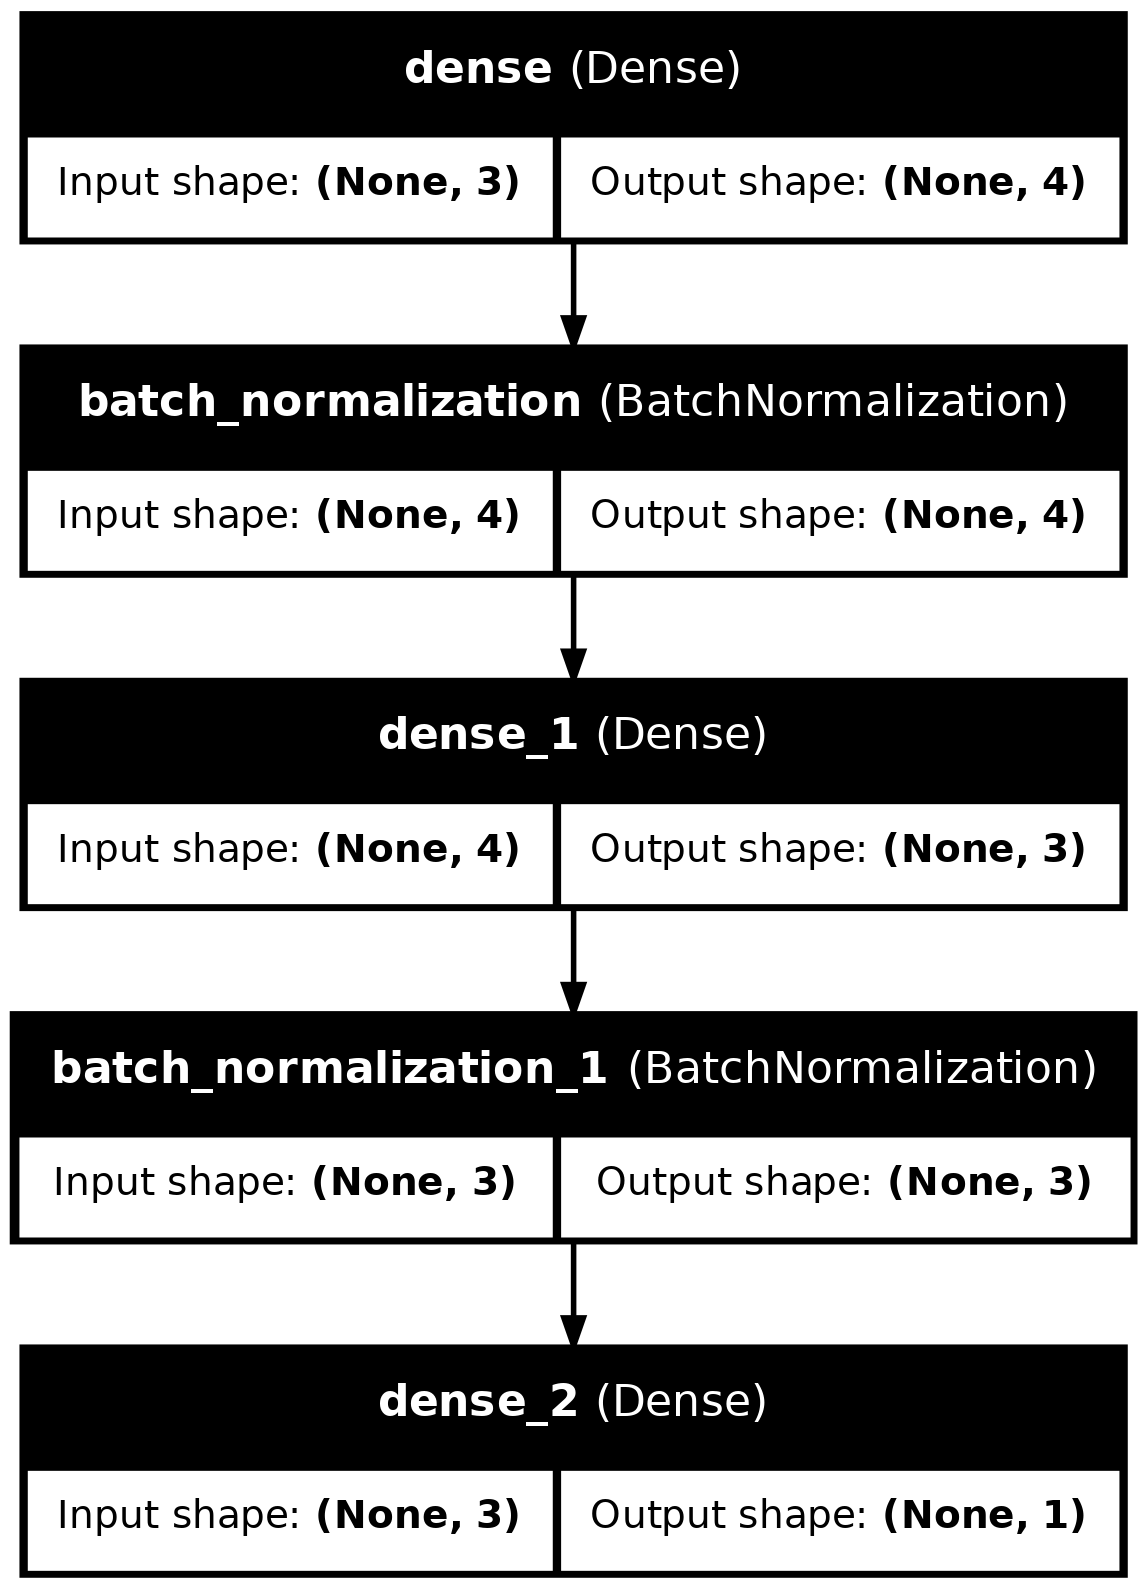

In [20]:
import pydot
import graphviz
import os
from IPython.display import display, Image
from matplotlib import pyplot
from keras import backend
from keras.layers import Dense, Dropout, Flatten, Activation, BatchNormalization
from keras import backend as K
K.clear_session()
def rmse(y_true, y_pred):
    return backend.sqrt(backend.mean(backend.square(y_pred - y_true), axis=-1))
# Định nghĩa mô hình mạng nơ-ron
nn_model = Sequential() 
# Thêm lớp đầu tiên với 4 nơ-ron, kích thước đầu vào là 3 (tương ứng với 3 cột dữ liệu), hàm kích hoạt là ReLU
nn_model.add(Dense(4, input_dim=3, activation='relu')) 
nn_model.add(BatchNormalization())
# Thêm lớp thứ hai với 3 nơ-ron, hàm kích hoạt là tanh
nn_model.add(Dense(3, activation='tanh')) 
nn_model.add(BatchNormalization())
# Thêm lớp đầu ra với 1 nơ-ron, hàm kích hoạt là tanh
nn_model.add(Dense(1,activation='tanh'))
# Biên dịch mô hình với hàm mất mát là binary_crossentropy, bộ tối ưu là adam, và theo dõi độ chính xác
nn_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# Huấn luyện mô hình với dữ liệu huấn luyện, số epoch là 100, và kích thước batch là 10
plot_model(nn_model,to_file='model_plot.png', show_shapes=True, show_layer_names=True)
i=Image("model_plot.png")
display(i)

## 5. Huấn luyện mạng nơ ron

In [24]:
from scipy import stats
import numpy as np

# Huấn luyện mô hình
history = nn_model.fit(
    X1.to_numpy(),
    Y1.to_numpy(),
    epochs=450,
    batch_size=10,
    verbose=0
)

# Đánh giá mô hình
results_train = nn_model.evaluate(
    X1.to_numpy(),
    Y1.to_numpy()
)

print('Loss function value - training set:', results_train[0])
print('Metrics value - training set:', results_train[1])

# Dự đoán
Y1_pred = nn_model.predict(X1.to_numpy())

# Chuyển giá trị dự đoán thành -1 hoặc 1
Y1_pred[Y1_pred >= 0] = 1
Y1_pred[Y1_pred < 0] = -1

# Tính accuracy
print("Success rate(%) - training set:",
      100 * np.sum(Y1_pred[:,0] == Y1.to_numpy()) / len(Y1))

print("Number of obs. per category in Y1 - training set")

# Thay stats.itemfreq
values, counts = np.unique(Y1.to_numpy(), return_counts=True)
print(np.column_stack((values, counts)))

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0287 - loss: -8.1978      
Loss function value - training set: -8.197779655456543
Metrics value - training set: 0.028688523918390274
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Success rate(%) - training set: 77.8688524590164
Number of obs. per category in Y1 - training set
[[ -1 179]
 [  1  65]]


## 6. Kiểm tra tập test mạng nơ ron 

In [26]:
# Dự đoán trên tập kiểm tra
Y2_pred= nn_model.predict(X2)
# Chuyển giá trị dự đoán thành -1 hoặc 1
Y2_pred[Y2_pred>=0]=1
Y2_pred[Y2_pred<0]=-1

print("Success rate(%) - testing set:",
      100 * np.sum(Y2_pred[:,0] == Y2.to_numpy()) / len(Y2))
print("Number of obs. per category in Y2 - testing set")
# Thay stats.itemfreq
print("\n\n")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Success rate(%) - testing set: 72.58064516129032
Number of obs. per category in Y2 - testing set



